# Pertemuan 9 - Algoritma Klasifikasi (Bagian 1): Logistic Regression & Decision Tree

**Nama:** Moch Faris Oldie  
**NIM:** 250401020048  
**Kelas:** IF401

**Tujuan:** mempelajari konsep klasifikasi, menerapkan Logistic Regression dan Decision Tree menggunakan scikit-learn, serta mengevaluasi model dengan Confusion Matrix, Accuracy, Precision, Recall, dan F1-Score pada dataset medis.

## 1. Load Dataset & EDA Singkat

Dataset yang digunakan adalah **Breast Cancer Wisconsin** (bawaan scikit-learn). Target berupa 0 = Malignant (ganas) dan 1 = Benign (jinak).

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0 = malignant, 1 = benign

print('Shape:', X.shape)
print('Distribusi target (0 = Malignant, 1 = Benign):')
print(pd.Series(y).value_counts(normalize=True).round(3))

Shape: (569, 30)
Distribusi target (0 = Malignant, 1 = Benign):
1    0.627
0    0.373
Name: proportion, dtype: float64


## 2. Preprocessing

Bagi data menjadi data latih dan data uji 80:20 dengan `stratify=y` agar proporsi kelas terjaga, lalu standarisasi fitur dengan `StandardScaler` (penting untuk Logistic Regression).

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print('Ukuran X_train:', X_train_s.shape)
print('Ukuran X_test :', X_test_s.shape)

Ukuran X_train: (455, 30)
Ukuran X_test : (114, 30)


## 3. Logistic Regression

Logistic Regression mengubah kombinasi linear fitur menjadi probabilitas melalui fungsi sigmoid. Feature scaling mempercepat konvergensi optimasi.

In [3]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000, random_state=42)
log_model.fit(X_train_s, y_train)
y_pred_log = log_model.predict(X_test_s)
y_proba_log = log_model.predict_proba(X_test_s)[:, 1]

# Fitur dengan koefisien terbesar (paling berpengaruh)
coef_df = pd.DataFrame({'Fitur': X.columns, 'Koefisien': log_model.coef_[0]})
coef_df = coef_df.sort_values('Koefisien', key=abs, ascending=False)
print(coef_df.head(8).to_string(index=False))

               Fitur  Koefisien
       worst texture  -1.255088
        radius error  -1.082965
worst concave points  -0.953686
          worst area  -0.947756
        worst radius  -0.947616
      worst symmetry  -0.939181
          area error  -0.929104
     worst concavity  -0.823151


Koefisien positif berarti fitur mendorong prediksi ke kelas 1 (Benign), sedangkan koefisien negatif mendorong ke kelas 0 (Malignant). Besarnya nilai absolut menunjukkan pengaruh fitur tersebut.

## 4. Decision Tree

Decision Tree membangun aturan if-else bertingkat. Pohon dibatasi dengan `max_depth=4` untuk mencegah overfitting. Decision Tree tidak memerlukan feature scaling.

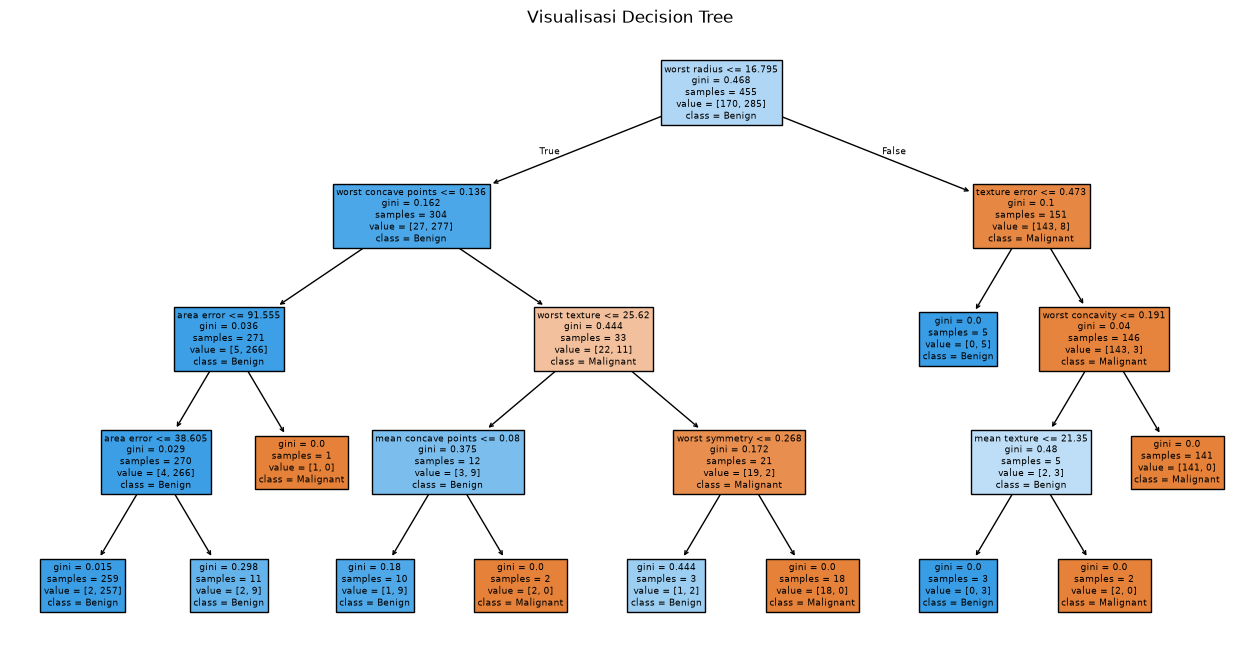

In [4]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

plt.figure(figsize=(16, 8))
plot_tree(tree_model, feature_names=X.columns,
          class_names=['Malignant', 'Benign'], filled=True)
plt.title('Visualisasi Decision Tree')
plt.show()

## 5. Evaluasi Kedua Model

Hitung Confusion Matrix, Accuracy, Precision, Recall, dan F1-Score untuk kedua model. Untuk kasus diagnosis medis, **Recall** menjadi metrik paling kritis karena False Negative berarti kanker terlewat.

In [5]:
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)

for name, y_pred in [('Logistic Regression', y_pred_log),
                      ('Decision Tree', y_pred_tree)]:
    print(f'=== {name} ===')
    print('Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))
    print(f'Accuracy : {accuracy_score(y_test, y_pred):.3f}')
    print(f'Precision: {precision_score(y_test, y_pred):.3f}')
    print(f'Recall   : {recall_score(y_test, y_pred):.3f}')
    print(f'F1-Score : {f1_score(y_test, y_pred):.3f}')
    print()

=== Logistic Regression ===
Confusion Matrix:
[[41  1]
 [ 1 71]]
Accuracy : 0.982
Precision: 0.986
Recall   : 0.986
F1-Score : 0.986

=== Decision Tree ===
Confusion Matrix:
[[39  3]
 [ 4 68]]
Accuracy : 0.939
Precision: 0.958
Recall   : 0.944
F1-Score : 0.951



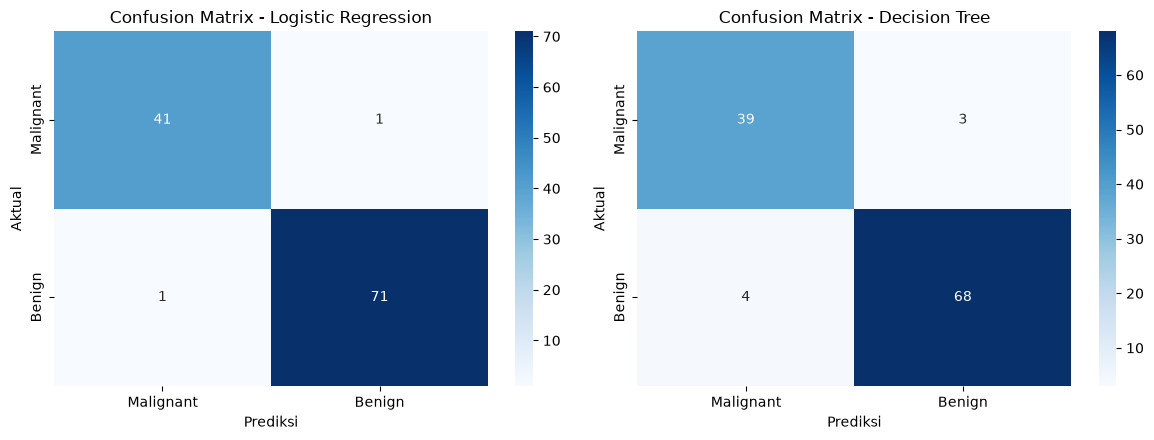

In [6]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (name, y_pred) in zip(axes, [('Logistic Regression', y_pred_log),
                                     ('Decision Tree', y_pred_tree)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Malignant', 'Benign'],
                yticklabels=['Malignant', 'Benign'])
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
plt.tight_layout()
plt.show()

## Interpretasi Hasil

Kedua model menampilkan confusion matrix, accuracy, precision, recall, dan F1-score. Untuk diagnosis medis, **Recall** lebih relevan daripada Accuracy karena False Negative (pasien ganas yang dikira jinak) jauh lebih berbahaya daripada False Positive. Model dengan recall lebih tinggi berarti lebih jarang melewatkan kasus positif, walaupun mungkin menghasilkan beberapa pemeriksaan lanjutan yang tidak perlu.

## Kesimpulan

Pada pertemuan ini saya mempelajari klasifikasi sebagai Supervised Learning yang memprediksi kategori diskret, lalu menerapkan dua algoritma dasar: Logistic Regression (probabilistik berbasis sigmoid, memerlukan scaling) dan Decision Tree (berbasis aturan if-else, tidak perlu scaling). Saya juga belajar menghitung dan menginterpretasikan Confusion Matrix, Accuracy, Precision, Recall, dan F1-Score. Temuan utama: pada kasus diagnosis medis, Recall lebih kritis daripada Accuracy karena False Negative (kanker terlewat) lebih berbahaya; kedua model menunjukkan performa yang baik pada dataset Breast Cancer. Keterbatasan praktik ini adalah dataset relatif bersih dan kecil, sehingga belum mencerminkan tantangan data nyata yang lebih berisik, serta belum mencoba threshold yang berbeda.